# Cargos e Secretarias — Base SIAPE

Este notebook mostra **como o quadro de servidores está distribuído** entre
cargos, secretarias, órgãos de exercício e níveis hierárquicos. Todos os números
são agregados (contagens e percentuais) — nenhum servidor é identificado
individualmente.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.viz_style import (
    aplicar_estilo_global,
    grafico_barra_horizontal,
    grafico_top_n_outros,
)

DATA_PATH = Path("../data/raw/DB_SIAPE_processado_20260729.xlsx")
df = pd.read_excel(DATA_PATH, engine="openpyxl")

aplicar_estilo_global()
TOTAL = len(df)

## Distribuição por Cargo

**O que este gráfico mostra**: quantos servidores ocupam cada cargo. A base tem
15 cargos diferentes, então mostramos todos.

In [2]:
contagem_cargo = df["Cargo"].value_counts()
tabela_cargo = pd.DataFrame({
    "quantidade": contagem_cargo,
    "percentual": (contagem_cargo / TOTAL * 100).round(1),
})
tabela_cargo

,quantidade,percentual
Cargo,,
ANALISTA TECNICO EXECUTIVO,5392,54.0
ANALISTA TECN EM POLITICAS SOCIAIS,1151,11.5
ESP POL PUBL GESTAO GOVERNAMENTAL,1026,10.3
ANALISTA DE INFRA-ESTRUTURA,991,9.9
PERITO FEDERAL TERRITORIAL - NS,721,7.2
ANALISTA EM TECNOL DA INFORMACAO,553,5.5
ADMINISTRADOR,58,0.6
ESPECIALISTA EM INFRA-ESTRUTURA SENIOR,49,0.5
TECNICO DE NIVEL SUPERIOR,24,0.2


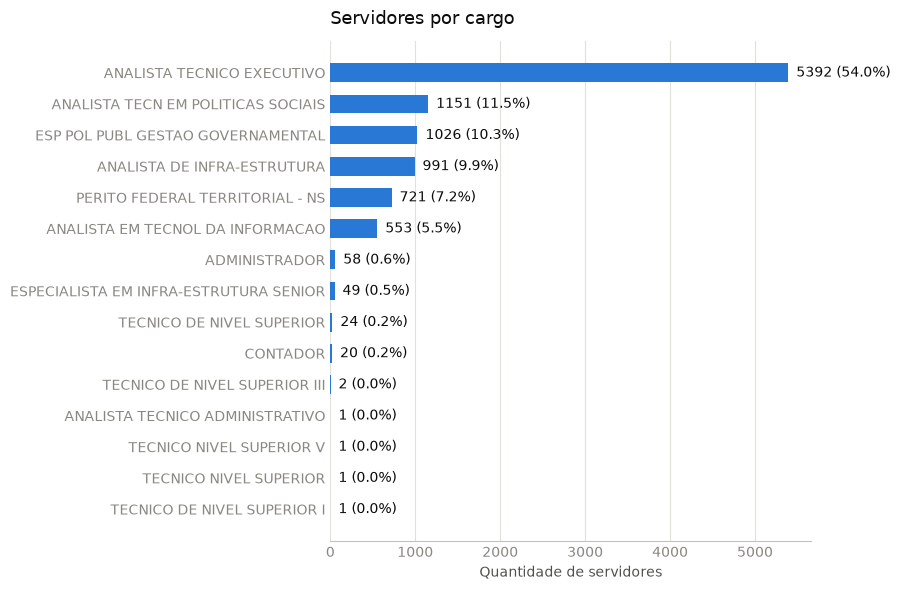

In [3]:
grafico_barra_horizontal(contagem_cargo, TOTAL, "Servidores por cargo", figsize=(9, 6))

## Distribuição por Secretaria

**O que este gráfico mostra**: em quais secretarias os servidores estão lotados.
A base tem 22 secretarias diferentes; mostramos as 10 maiores. O restante aparece
agrupado em cinza como "Outros", sempre na base do gráfico.

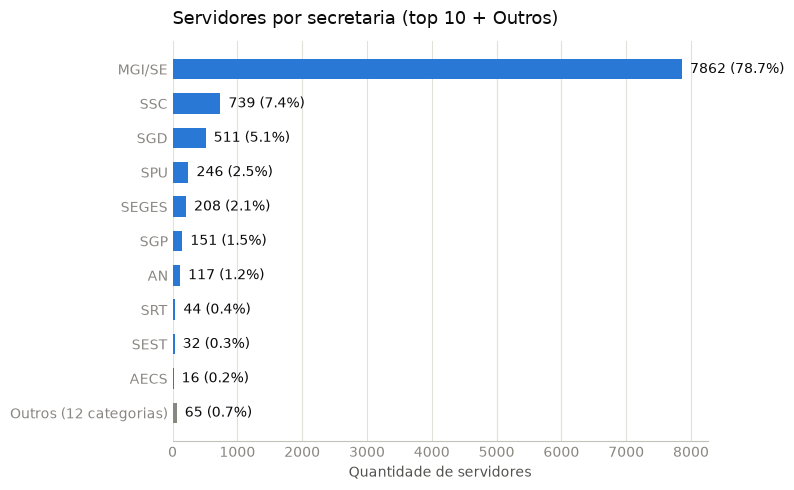

,quantidade,percentual
Secretaria,,
MGI/SE,7862,78.7
SSC,739,7.4
SGD,511,5.1
SPU,246,2.5
SEGES,208,2.1
SGP,151,1.5
AN,117,1.2
SRT,44,0.4
SEST,32,0.3


In [4]:
contagem_secretaria = grafico_top_n_outros(df["Secretaria"], TOTAL, "Servidores por secretaria (top 10 + Outros)")

tabela_secretaria = pd.DataFrame({
    "quantidade": contagem_secretaria.head(10),
    "percentual": (contagem_secretaria.head(10) / TOTAL * 100).round(1),
})
tabela_secretaria

## Distribuição por Órgão de Exercício

**O que este gráfico mostra**: em quais órgãos (ministérios, autarquias, etc.) os
servidores efetivamente trabalham. A base tem 143 órgãos diferentes; mostramos os
10 maiores. O restante aparece agrupado em cinza como "Outros", sempre na base do
gráfico — para não parecer um único órgão gigante.

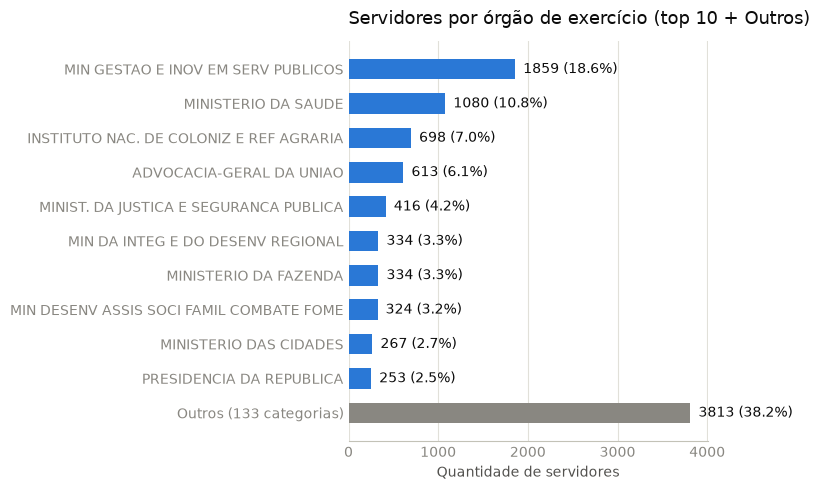

,quantidade,percentual
Órgão de Exercício,,
MIN GESTAO E INOV EM SERV PUBLICOS,1859,18.6
MINISTERIO DA SAUDE,1080,10.8
INSTITUTO NAC. DE COLONIZ E REF AGRARIA,698,7.0
ADVOCACIA-GERAL DA UNIAO,613,6.1
MINIST. DA JUSTICA E SEGURANCA PUBLICA,416,4.2
MINISTERIO DA FAZENDA,334,3.3
MIN DA INTEG E DO DESENV REGIONAL,334,3.3
MIN DESENV ASSIS SOCI FAMIL COMBATE FOME,324,3.2
MINISTERIO DAS CIDADES,267,2.7


In [5]:
contagem_orgao = grafico_top_n_outros(df["Órgão de Exercício"], TOTAL, "Servidores por órgão de exercício (top 10 + Outros)")

tabela_orgao = pd.DataFrame({
    "quantidade": contagem_orgao.head(10),
    "percentual": (contagem_orgao.head(10) / TOTAL * 100).round(1),
})
tabela_orgao

## Distribuição por Hierarquia do Cargo

**O que este gráfico mostra**: quantos servidores ocupam posições de comissão
(DAS ou equivalente, do nível 1 ao 6) versus posições sem cargo de chefia
registrado ("NI" = não informado / não se aplica).

In [6]:
contagem_hierarquia = df["Hierarquia do cargo_Cargos"].value_counts()
tabela_hierarquia = pd.DataFrame({
    "quantidade": contagem_hierarquia,
    "percentual": (contagem_hierarquia / TOTAL * 100).round(1),
})
tabela_hierarquia

,quantidade,percentual
Hierarquia do cargo_Cargos,,
NI,8662,86.7
DAS-4 ou equivalente,417,4.2
DAS-3 ou equivalente,408,4.1
DAS-2 ou equivalente,194,1.9
DAS-5 ou equivalente,159,1.6
DAS-1 ou equivalente,85,0.9
DAS-6 ou equivalente,48,0.5
Natureza Especial ou equivalente,18,0.2


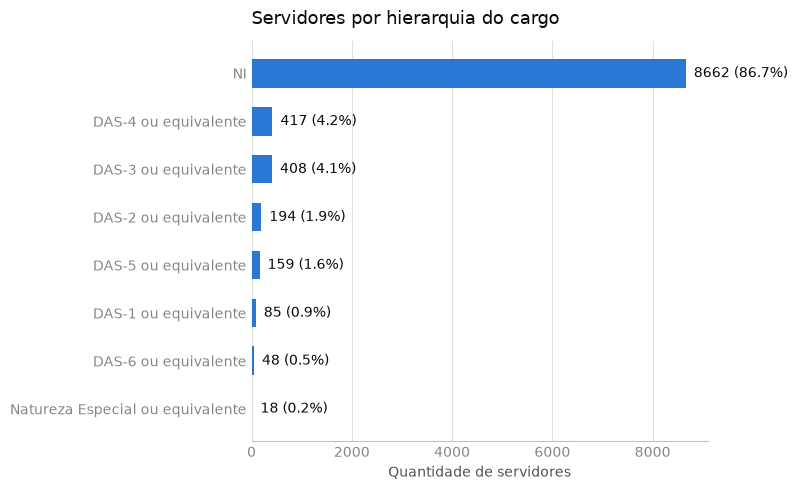

In [7]:
grafico_barra_horizontal(contagem_hierarquia, TOTAL, "Servidores por hierarquia do cargo")

## Resumo consolidado

In [8]:
from IPython.display import Markdown, display

cargo_predominante = contagem_cargo.idxmax()
pct_cargo_predominante = round(contagem_cargo.max() / TOTAL * 100, 1)
secretaria_predominante = contagem_secretaria.idxmax()
pct_secretaria_predominante = round(contagem_secretaria.max() / TOTAL * 100, 1)
orgao_predominante = contagem_orgao.idxmax()
pct_orgao_predominante = round(contagem_orgao.max() / TOTAL * 100, 1)
pct_ni_hierarquia = round(contagem_hierarquia.get("NI", 0) / TOTAL * 100, 1)
pct_com_das = round(100 - pct_ni_hierarquia, 1)

resumo_md = f"""
- O cargo mais comum e **{cargo_predominante.title()}**, concentrando **{pct_cargo_predominante}%** dos servidores.
- A secretaria com mais servidores e **{secretaria_predominante}**, com **{pct_secretaria_predominante}%** do total.
- O orgao de exercicio com mais servidores e **{orgao_predominante}**, com **{pct_orgao_predominante}%** do total.
- **{pct_com_das}%** dos servidores possuem alguma hierarquia de cargo registrada (DAS ou equivalente); os demais **{pct_ni_hierarquia}%** nao tem essa informacao preenchida (NI).

Esses numeros descrevem o quadro como um todo — nenhum servidor especifico foi identificado nesta analise.
"""

display(Markdown(resumo_md))


- O cargo mais comum e **Analista Tecnico Executivo**, concentrando **54.0%** dos servidores.
- A secretaria com mais servidores e **MGI/SE**, com **78.7%** do total.
- O orgao de exercicio com mais servidores e **MIN GESTAO E INOV EM SERV PUBLICOS**, com **18.6%** do total.
- **13.3%** dos servidores possuem alguma hierarquia de cargo registrada (DAS ou equivalente); os demais **86.7%** nao tem essa informacao preenchida (NI).

Esses numeros descrevem o quadro como um todo — nenhum servidor especifico foi identificado nesta analise.
